In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Introduction
"Emotions" dataset" – a collection of English Twitter messages meticulously annotated with six fundamental emotions classified into six categories: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5).  This dataset serves as a valuable resource for understanding and analyzing the diverse spectrum of emotions expressed in short-form text on social media.

# Step 1: Import necessary libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from wordcloud import WordCloud
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Data Loading

In [14]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv("text.csv")

# Display the first few rows of the dataset
print("First few rows of the dataset:")
data

First few rows of the dataset:


,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  416809 non-null  int64 
 1   text        416809 non-null  object
 2   label       416809 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 9.5+ MB


In [10]:
data.describe()

,Unnamed: 0,label
count,416809.000000,416809.000000
mean,208404.000000,1.554271
std,120322.538513,1.490453
min,0.000000,0.000000
25%,104202.000000,0.000000
50%,208404.000000,1.000000
75%,312606.000000,3.000000
max,416808.000000,5.000000


In [11]:
# Emotion Distribution
emotion_distribution = data['label'].value_counts()
print(emotion_distribution)

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64


# Step 3: EDA

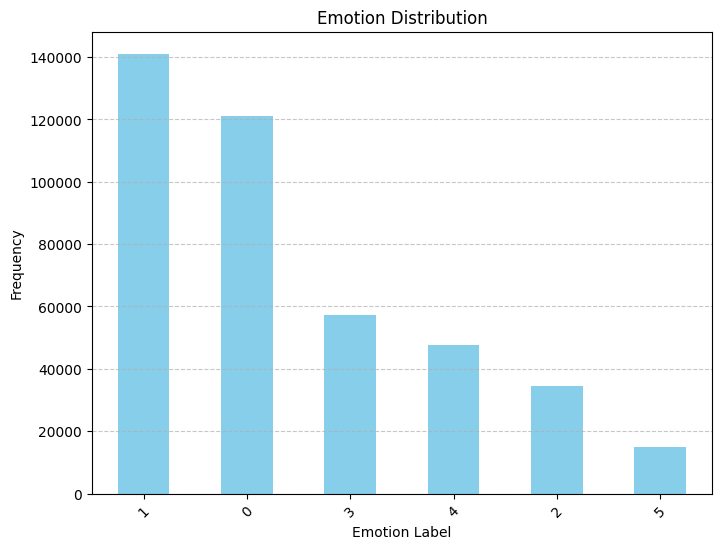

In [12]:
# 1. Plotting the emotion distribution
plt.figure(figsize=(8, 6))
emotion_distribution.plot(kind='bar', color='skyblue')
plt.title('Emotion Distribution')
plt.xlabel('Emotion Label')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


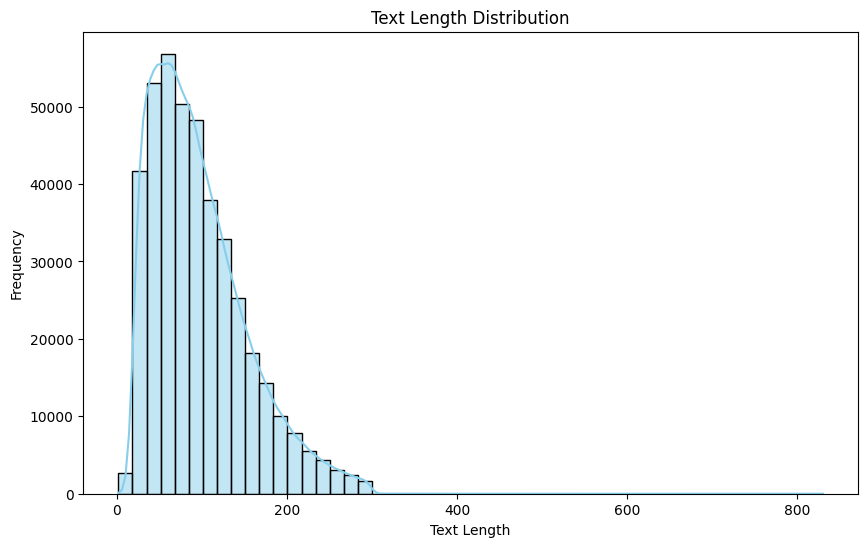

In [13]:
# 2. Text Length Distribution
data['text_length'] = data['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(data['text_length'], bins=50, color='skyblue', kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()


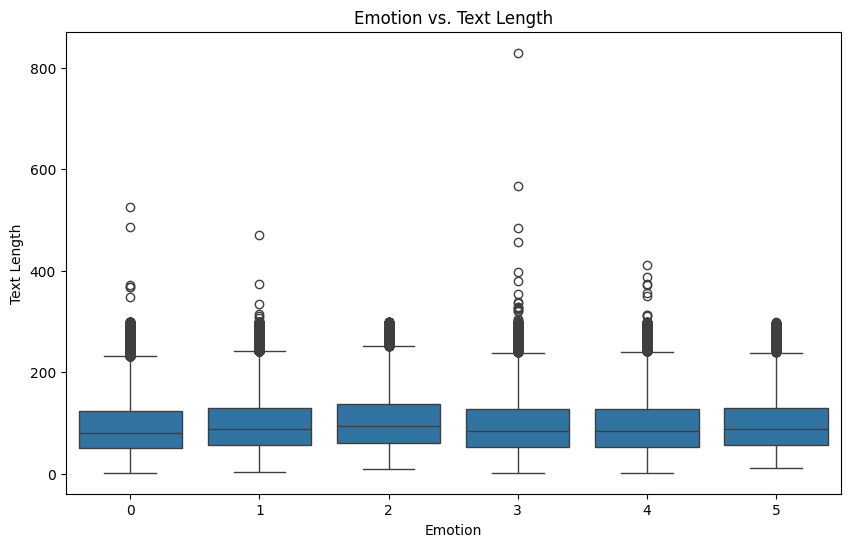

In [14]:
# 3. Emotion vs. Text Length
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='text_length', data=data)
plt.title('Emotion vs. Text Length')
plt.xlabel('Emotion')
plt.ylabel('Text Length')
plt.show()


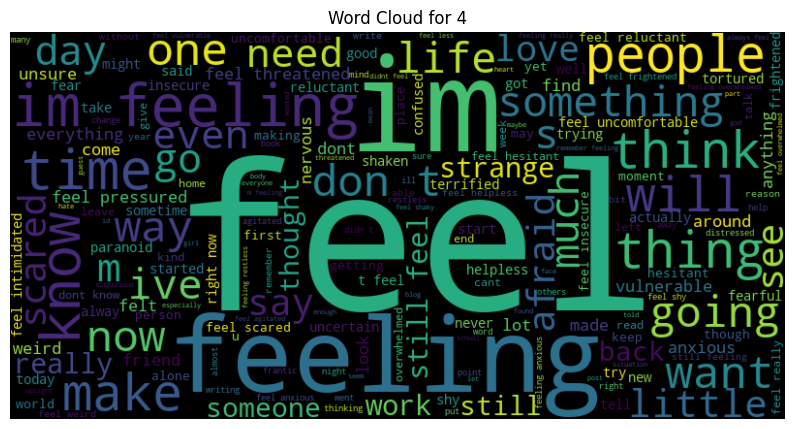

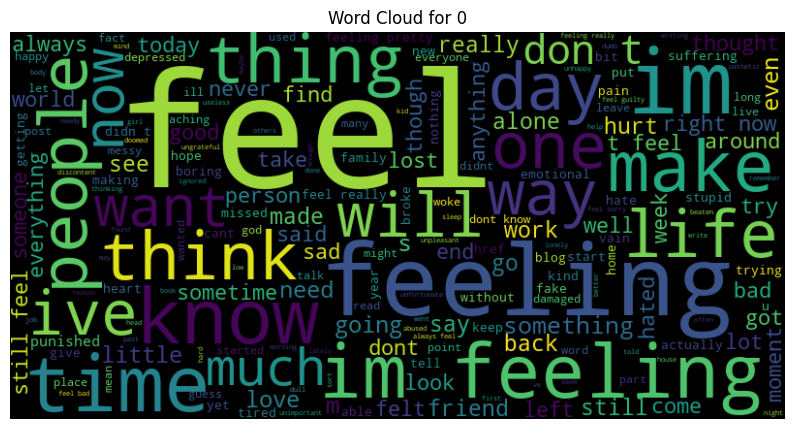

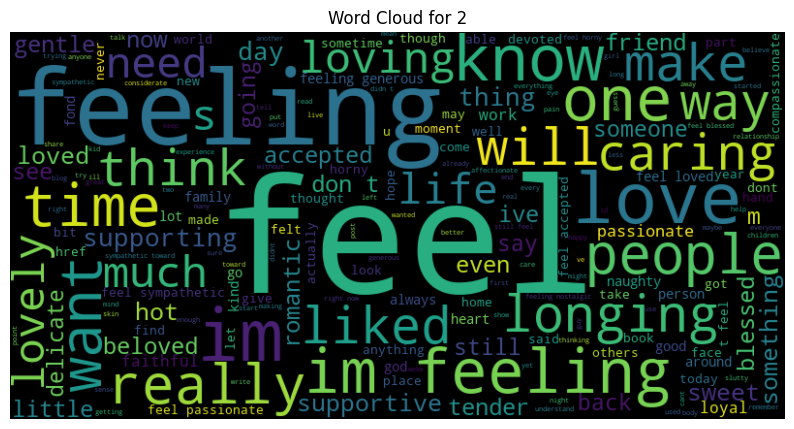

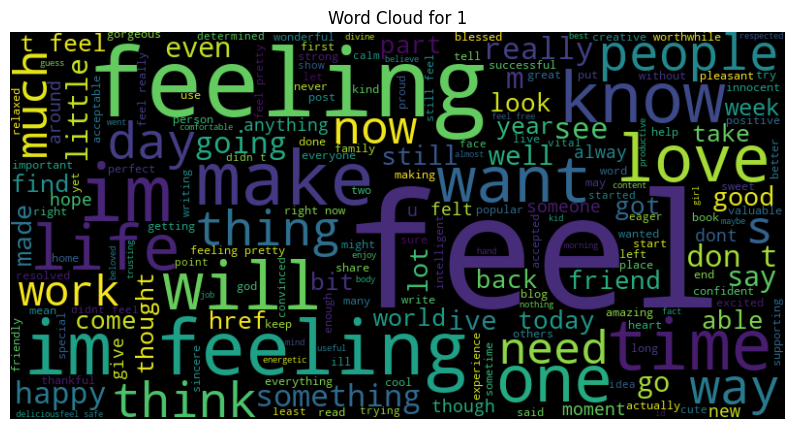

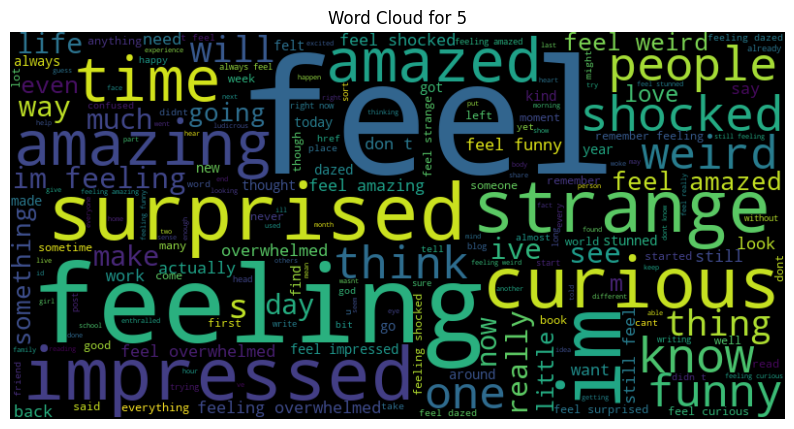

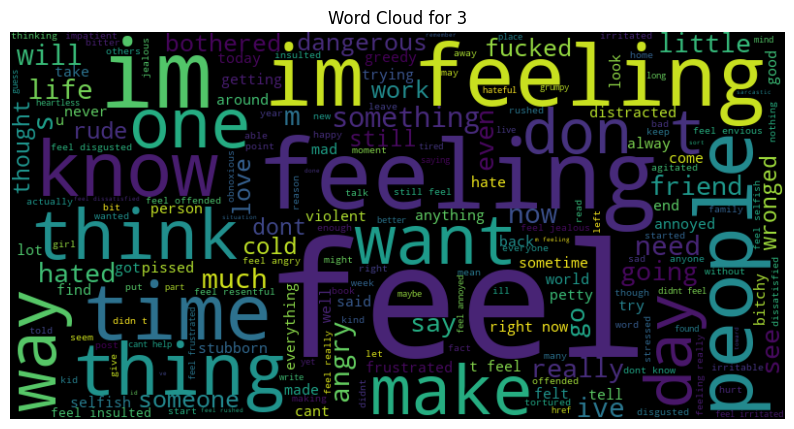

In [15]:
# 4. Word Cloud for Each Emotion
emotions = data['label'].unique()
for emotion in emotions:
    text = ' '.join(data[data['label'] == emotion]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {emotion}')
    plt.axis('off')
    plt.show()

# Step 4:Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)


# Step 5: Text Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)


# Step 6:Model Training and Evaluation

In [ ]:
# 1. Pretrained Transformer Model (Emotion Classification)
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib
import torch
import numpy as np
import pandas as pd

# Ensure required variables exist even if previous cells were not executed
if 'data' not in globals():
    data = pd.read_csv("text.csv")

if 'X_test' not in globals() or 'y_test' not in globals() or 'X_train' not in globals() or 'y_train' not in globals():
    X_train, X_test, y_train, y_test = train_test_split(
        data['text'],
        data['label'],
        test_size=0.2,
        random_state=42
    )
    print("Auto-created train/test split for evaluation.")

# Initialize the pretrained emotion classification pipeline using a publicly available model
device_id = 0 if torch.cuda.is_available() else -1
emotion_classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion",
    device=device_id,
)

# Map model's label indices to emotion names
emotion_label_map = {
    "sadness": 0,      # Sadness
    "joy": 1,          # Joy
    "love": 2,         # Love
    "anger": 3,        # Anger
    "fear": 4,         # Fear
    "surprise": 5,     # Surprise
}

# Make predictions on test set using batch processing (much faster)
print("Classifying test samples with pretrained emotion model...")
print(f"Total samples to classify: {len(X_test)}")

# Convert to list and limit text length
test_texts = [text[:512] for text in X_test.values]

# Use batch processing for faster inference
batch_size = 32
y_pred_transformer = []
confidence_scores = []

for batch_idx in range(0, len(test_texts), batch_size):
    batch = test_texts[batch_idx:batch_idx + batch_size]
    results = emotion_classifier(batch)

    for result in results:
        raw_label = result['label'].lower().strip()
        if raw_label.startswith('label_') and raw_label.split('_')[-1].isdigit():
            predicted_label = int(raw_label.split('_')[-1])
        else:
            predicted_label = emotion_label_map.get(raw_label, 0)
        y_pred_transformer.append(predicted_label)
        confidence_scores.append(result['score'])

    if (batch_idx // batch_size + 1) % 10 == 0:
        print(f"  Processed {min(batch_idx + batch_size, len(test_texts))}/{len(test_texts)} samples")

y_pred_transformer = np.array(y_pred_transformer)

# Evaluate the model
accuracy_transformer = accuracy_score(y_test, y_pred_transformer)
print(f"\nAccuracy (Pretrained Emotion Model): {accuracy_transformer:.4f}")

# Classification report
print("\nClassification Report (Pretrained Emotion Model):")
print(classification_report(
    y_test,
    y_pred_transformer,
    labels=[0, 1, 2, 3, 4, 5],
    target_names=['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
))

# Confusion matrix
print("\nConfusion Matrix (Pretrained Emotion Model):")
print(confusion_matrix(y_test, y_pred_transformer))

# Save model pipeline for reuse
joblib.dump(emotion_classifier, "emotion_transformer_model.joblib")
print("\nSaved: emotion_transformer_model.joblib")
print(f"Average confidence: {np.mean(confidence_scores):.4f}")

Auto-created train/test split for evaluation.


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3245.79it/s]


Classifying test samples with pretrained emotion model...
Total samples to classify: 83362
  Processed 320/83362 samples
  Processed 640/83362 samples
  Processed 960/83362 samples
  Processed 1280/83362 samples
  Processed 1600/83362 samples
  Processed 1920/83362 samples
  Processed 2240/83362 samples
  Processed 2560/83362 samples
  Processed 2880/83362 samples
  Processed 3200/83362 samples
  Processed 3520/83362 samples
  Processed 3840/83362 samples
  Processed 4160/83362 samples
  Processed 4480/83362 samples
  Processed 4800/83362 samples
  Processed 5120/83362 samples
  Processed 5440/83362 samples
  Processed 5760/83362 samples
  Processed 6080/83362 samples
  Processed 6400/83362 samples
  Processed 6720/83362 samples
  Processed 7040/83362 samples
  Processed 7360/83362 samples
  Processed 7680/83362 samples
  Processed 8000/83362 samples
  Processed 8320/83362 samples
  Processed 8640/83362 samples
  Processed 8960/83362 samples
  Processed 9280/83362 samples
  Processed 9

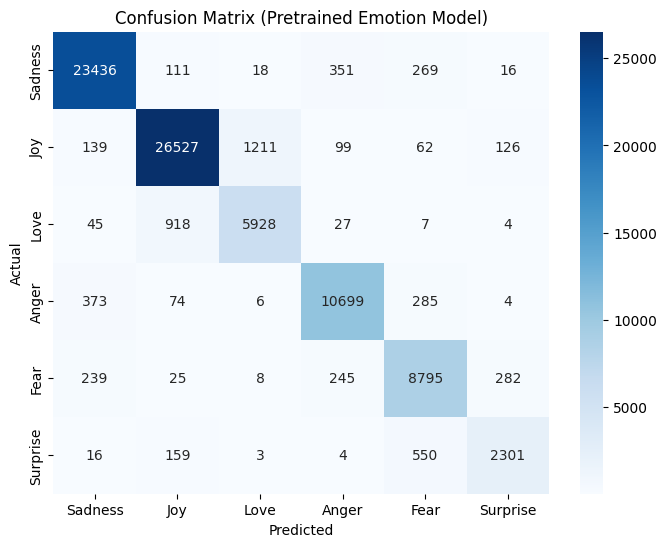


Classification Report (Pretrained Emotion Model):
              precision    recall  f1-score   support

     Sadness       0.97      0.97      0.97     24201
         Joy       0.95      0.94      0.95     28164
        Love       0.83      0.86      0.84      6929
       Anger       0.94      0.94      0.94     11441
        Fear       0.88      0.92      0.90      9594
    Surprise       0.84      0.76      0.80      3033

    accuracy                           0.93     83362
   macro avg       0.90      0.90      0.90     83362
weighted avg       0.93      0.93      0.93     83362



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

if 'y_test' not in globals() or 'y_pred_transformer' not in globals():
    raise NameError("Run Cell 20 first to generate y_test and y_pred_transformer.")

# Function to plot confusion matrix
def plot_confusion_matrix(cm, labels, title='Confusion Matrix', figsize=(8, 6)):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot confusion matrix for pretrained transformer model
plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_transformer),
    labels=['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise'],
    title='Confusion Matrix (Pretrained Emotion Model)'
)

# Print classification report for pretrained transformer model
print("\nClassification Report (Pretrained Emotion Model):")
print(classification_report(
    y_test,
    y_pred_transformer,
    labels=[0, 1, 2, 3, 4, 5],
    target_names=['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
))

In [13]:
# Load saved transformer model and classify custom text
import joblib
import numpy as np
from pathlib import Path

base_dir = Path.cwd()
model_path = base_dir / "emotion_transformer_model.joblib"

# Fall back to models directory when running from project root
if not model_path.exists():
    model_path = base_dir / "models" / "emotion_transformer_model.joblib"

# Load the pretrained transformer pipeline
loaded_model = joblib.load(model_path)

label_map = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise",
}

emotion_label_map = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5,
}

user_text = input("Enter text to classify emotion: ").strip()

if user_text:
    result = loaded_model(user_text[:512])
    raw_label = result[0]['label'].lower().strip()
    if raw_label.startswith('label_') and raw_label.split('_')[-1].isdigit():
        predicted_label_idx = int(raw_label.split('_')[-1])
    else:
        predicted_label_idx = emotion_label_map.get(raw_label, 0)
    confidence = result[0]['score']
    print(f"\nPredicted emotion: {label_map[predicted_label_idx]}")
    print(f"Confidence: {confidence:.4f}")
else:
    print("No text entered.")


Predicted emotion: Sadness
Confidence: 0.9218
